In [28]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder 
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [29]:
# Load YOUR own CSV file
df = pd.read_csv('IRIS.csv')   

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (150, 5)

Columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

First 5 rows:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [30]:

print(df.info())

print(df['species'].value_counts())

print("\nStatistical Summary:")
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Statistical Summary:


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


<Figure size 1000x600 with 0 Axes>

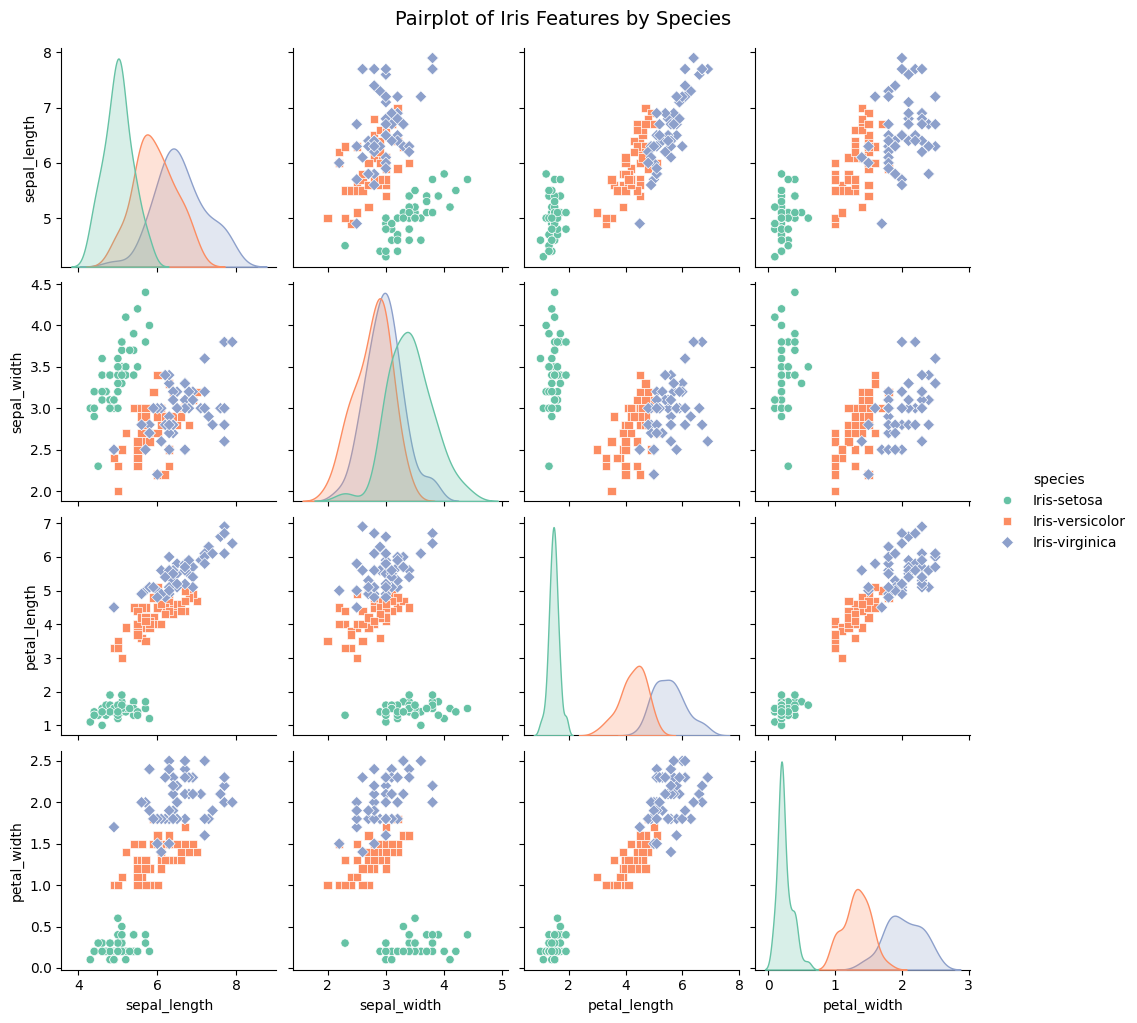

In [31]:
plt.figure(figsize=(10, 6))
sns.pairplot(df, hue='species', palette='Set2', diag_kind='kde', markers=['o', 's', 'D'])
plt.suptitle('Pairplot of Iris Features by Species', y=1.02, fontsize=14)
plt.show()

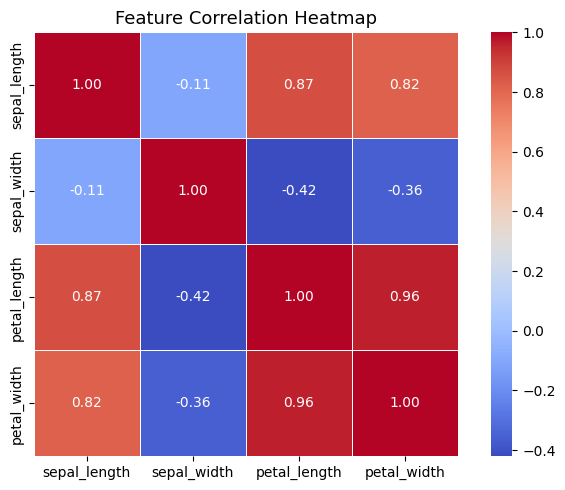

In [32]:
plt.figure(figsize=(7, 5))
sns.heatmap(df.iloc[:, :-1].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.show()

In [33]:
# Features and Target
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values

# Encode species names to numbers
# Iris-setosa → 0, Iris-versicolor → 1, Iris-virginica → 2
le = LabelEncoder()
y = le.fit_transform(df['species'])

print("Classes:", le.classes_)
print("y sample:", y[:5])

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"\nTraining samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")
print("NaN in X_train  :", np.isnan(X_train).sum())

Classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
y sample: [0 0 0 0 0]

Training samples : 120
Testing  samples : 30
NaN in X_train  : 0


In [40]:
# Define model
models = {
    'K-Nearest Neighbors' : KNeighborsClassifier(n_neighbors=5),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name:25s} → Accuracy: {acc*100:.2f}%")

K-Nearest Neighbors       → Accuracy: 93.33%
Decision Tree             → Accuracy: 90.00%
Random Forest             → Accuracy: 90.00%


In [41]:

best_model = models['Random Forest']
y_pred     = best_model.predict(X_test)

print("=" * 50)
print("   CLASSIFICATION REPORT — Random Forest")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=iris.target_names))

   CLASSIFICATION REPORT — Random Forest
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



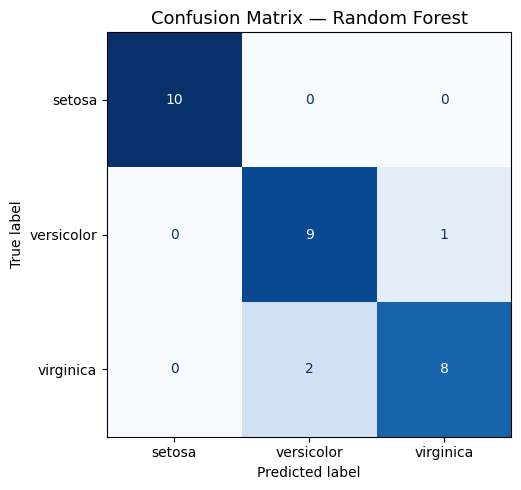

In [42]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=iris.target_names)
disp.plot(cmap='Blues', ax=ax, colorbar=False)
plt.title('Confusion Matrix — Random Forest', fontsize=13)
plt.tight_layout()
plt.show()

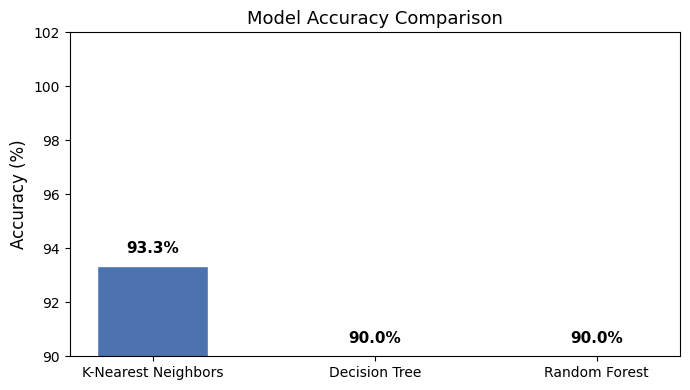

In [43]:
plt.figure(figsize=(7, 4))
colors = ['#4C72B0', '#55A868', '#C44E52']
bars = plt.bar(results.keys(), [v*100 for v in results.values()],
               color=colors, edgecolor='white', width=0.5)

for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val*100:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.ylim(90, 102)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Model Accuracy Comparison', fontsize=13)
plt.xticks(fontsize=10)
plt.tight_layout()
plt.show()

In [45]:
# Predict species for a new flower measurement
# [sepal length, sepal width, petal length, petal width] in cm
new_sample = np.array([[5.1, 3.5, 1.4, 0.2]])   # try changing these values!

new_sample_scaled = scaler.transform(new_sample)
prediction        = best_model.predict(new_sample_scaled)
probability       = best_model.predict_proba(new_sample_scaled)

print("Input measurements:")
print(f"  Sepal Length: {new_sample[0][0]} cm")
print(f"  Sepal Width : {new_sample[0][1]} cm")
print(f"  Petal Length: {new_sample[0][2]} cm")
print(f"  Petal Width : {new_sample[0][3]} cm")
print()
print(f"Predicted Species : {iris.target_names[prediction[0]].upper()}")
print()
print("Prediction Probabilities:")
for name, prob in zip(iris.target_names, probability[0]):
    bar = '█' * int(prob * 20)
    print(f"  {name:12s}: {prob*100:5.1f}%  {bar}")

Input measurements:
  Sepal Length: 5.1 cm
  Sepal Width : 3.5 cm
  Petal Length: 1.4 cm
  Petal Width : 0.2 cm

Predicted Species : SETOSA

Prediction Probabilities:
  setosa      : 100.0%  ████████████████████
  versicolor  :   0.0%  
  virginica   :   0.0%  
